# Rheological data DTS / Loss modulus - Preprocessing

**Author:** Lab of Farm Structures
**Date:** 2026-05

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import math
import re

## Import Data

In [2]:
database = 'Rheological Properties Data Libraries of mcl-PHAs'

## Create DataFrames for data points and properties

In [3]:
# Physicochemical properties DataFrame
df_physicochem = pd.read_excel(f'{database}.xlsx', sheet_name='Physchem_properties')

# Complex viscosity properties DataFrame
df_loss = pd.read_excel(f'{database}.xlsx', sheet_name='converted_MPa_Loss_modulus_G')

# Temperature DataFrame
df_temp = pd.read_excel(f'{database}.xlsx', sheet_name='Temperature(°C)')

# Experimental details DataFrame
df_exp = pd.read_excel(f'{database}.xlsx', sheet_name='Rheological_experimental_detail')

## Drop duplicates and remove multiple study+instance case (keep first)

In [4]:
print("Physicochemical Properties, rows before:", df_physicochem.shape[0])
df_physicochem = df_physicochem.drop_duplicates(subset=['Study_id', 'Instance'])
print("Physicochemical Properties, rows after:", df_physicochem.shape[0])

Physicochemical Properties, rows before: 38
Physicochemical Properties, rows after: 38


## Keep DTS data

In [5]:
exp_dict_dfs = (
    df_exp[df_exp['Test type'] == 'DTS']
    .groupby('Study_id')['Instance']
    .apply(list)
    .to_dict()
)

In [6]:
# Flatten exp_dict_dfs into a DataFrame of valid (Study_id, Instance) pairs
exp_pairs = [(sid, inst) for sid, instances in exp_dict_dfs.items() for inst in instances]
df_exp_pairs = pd.DataFrame(exp_pairs, columns=['Study_id', 'Instance'])

# Filter df_loss
df_loss_filtered = df_loss.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# Filter df_temp
df_temp_filtered = df_temp.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# Filter df_exp
df_exp_filtered = df_exp.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# FIlter df_physicochem
df_physic_filtered = df_physicochem.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# Check all dfs have the same rows
df_loss_filtered.shape, df_temp_filtered.shape, df_exp_filtered.shape, df_physic_filtered.shape

((24, 38), (24, 38), (24, 18), (24, 48))

## Merge properties

In [7]:
df_merged_prop = pd.merge(df_physic_filtered, df_exp_filtered,  on=['Study_id', 'Instance'], how='left')
df_merged_prop.tail()

,Study_id,Instance,initial_scl PHA ratio,initial_3HB ratio,initial_3HV ratio,initial_mcl PHA ratio,3HHx ratio,3HHp ratio,3HO ratio,3HN ratio,...,diameter,thickness,size units,Angular_frequency_units,Texp,Texp_units,Viscosity_units,Modulus_units,Strain_fixed(%),Frequency_experimental_fixed (Hz)
19,9,4,0.0,0.0,0.0,100.0,NaN,0.0,86.0,0.0,...,NaN,NaN,NaN,Hz,NaN,celsius,NaN,Pa,NaN,1.0
20,9,6,0.0,0.0,0.0,100.0,NaN,0.0,86.0,0.0,...,NaN,NaN,NaN,Hz,NaN,celsius,NaN,Pa,NaN,1.0
21,9,7,0.0,0.0,0.0,100.0,NaN,0.0,86.0,0.0,...,NaN,NaN,NaN,Hz,NaN,celsius,NaN,Pa,NaN,1.0
22,10,1,0.0,0.0,0.0,104.0,5.0,0.0,20.0,0.0,...,NaN,NaN,NaN,NaN,NaN,celsius,NaN,NaN,NaN,1.6
23,11,1,1.0,1.0,0.0,99.0,2.0,0.0,25.0,0.0,...,NaN,NaN,NaN,NaN,NaN,celsius,NaN,NaN,NaN,1.6


## Melt temperature values

In [8]:
id_cols = ["Study_id", "Instance"]

value_cols = [c for c in df_temp_filtered.columns if c not in id_cols]

df_temp_filtered[value_cols] = df_temp_filtered[value_cols].apply(
    pd.to_numeric, errors="coerce"
)
f_long = (
    df_temp_filtered
    .set_index(id_cols)[value_cols]
    .stack()
    .reset_index(name="f_value")
    .dropna(subset=["f_value"])
)
f_long.head()

,Study_id,Instance,level_2,f_value
0,3.0,1a,Unnamed: 2,-123.0
1,3.0,1a,Unnamed: 3,-115.0
2,3.0,1a,Unnamed: 4,-105.0
3,3.0,1a,Unnamed: 5,-95.0
4,3.0,1a,Unnamed: 6,-85.0


## Melt loss modulus values

In [9]:
id_cols = ["Study_id", "Instance"]

value_cols = [c for c in df_loss_filtered.columns if c not in id_cols]

df_loss_filtered[value_cols] = df_loss_filtered[value_cols].apply(
    pd.to_numeric, errors="coerce"
)
v_long = (
    df_loss_filtered
    .set_index(id_cols)[value_cols]
    .stack()
    .reset_index(name="v_value")
    .dropna(subset=["v_value"])
)
v_long.head()

,Study_id,Instance,level_2,v_value
0,7,1,Unnamed: 2,1220.086
1,7,1,Unnamed: 3,918.996
2,7,1,Unnamed: 4,669.939
3,7,1,Unnamed: 5,556.624
4,7,1,Unnamed: 6,452.503


## Merge f and v values

In [10]:
fv_df = (
    f_long.merge(
        v_long,
        on=["Study_id", "Instance", "level_2"],
        how="inner",
#        validate="one_to_one"
    )
)
fv_df.head()

,Study_id,Instance,level_2,f_value,v_value
0,7.0,1,Unnamed: 2,100.0,1220.086
1,7.0,1,Unnamed: 3,105.0,918.996
2,7.0,1,Unnamed: 4,110.0,669.939
3,7.0,1,Unnamed: 5,115.0,556.624
4,7.0,1,Unnamed: 6,120.0,452.503


In [11]:
# check size
f_long.shape, v_long.shape, fv_df.shape

((485, 4), (323, 4), (319, 5))

## Merge properties with f,v values

In [12]:
df_merged_fnl = df_merged_prop.merge(
    fv_df[['Study_id', 'Instance', 'f_value', 'v_value']],
    on=['Study_id', 'Instance'],
    how='left'
)
df_merged_fnl = df_merged_fnl.dropna(subset=['f_value', 'v_value'])
df_merged_fnl.tail()

,Study_id,Instance,initial_scl PHA ratio,initial_3HB ratio,initial_3HV ratio,initial_mcl PHA ratio,3HHx ratio,3HHp ratio,3HO ratio,3HN ratio,...,size units,Angular_frequency_units,Texp,Texp_units,Viscosity_units,Modulus_units,Strain_fixed(%),Frequency_experimental_fixed (Hz),f_value,v_value
326,11,1,1.0,1.0,0.0,99.0,2.0,0.0,25.0,0.0,...,NaN,NaN,NaN,celsius,NaN,NaN,NaN,1.6,25.0,149.841431
327,11,1,1.0,1.0,0.0,99.0,2.0,0.0,25.0,0.0,...,NaN,NaN,NaN,celsius,NaN,NaN,NaN,1.6,35.0,142.463966
328,11,1,1.0,1.0,0.0,99.0,2.0,0.0,25.0,0.0,...,NaN,NaN,NaN,celsius,NaN,NaN,NaN,1.6,45.0,71.799093
329,11,1,1.0,1.0,0.0,99.0,2.0,0.0,25.0,0.0,...,NaN,NaN,NaN,celsius,NaN,NaN,NaN,1.6,55.0,13.681861
330,11,1,1.0,1.0,0.0,99.0,2.0,0.0,25.0,0.0,...,NaN,NaN,NaN,celsius,NaN,NaN,NaN,1.6,65.0,2.623114


In [13]:
df_merged_fnl.shape

(319, 66)

## Rename columns

In [14]:
df_merged_fnl = df_merged_fnl.rename(columns={
    'f_value': 'temperature',
    'v_value': 'loss_modulus'
})

df_merged_fnl.columns

Index(['Study_id', 'Instance', 'initial_scl PHA ratio', 'initial_3HB ratio',
       'initial_3HV ratio', 'initial_mcl PHA ratio', '3HHx ratio',
       '3HHp ratio', '3HO ratio', '3HN ratio', '3HD ratio', '3HUD ratio',
       '3HDD ratio', '3HTriD ratio', '3HTTD ratio',
       'Unsaturated monomer ratio', 'Uknown monomer ratio', 'Mw', 'Mn',
       'Density', 'Density_units', 'PDI', 'Additive', 'Additive1_type',
       'Additive1_name', 'Additive1_percentage', 'Additive_2',
       'Additive2_type', 'Additive2_name', 'Additive2_percentage',
       'final_PHA_percentage', 'formulation_scl PHA ratio',
       'formulation_3HB ratio', 'formulation_3HV ratio',
       'formulation_mcl PHA ratio', 'formulation_3HHx ratio',
       'formulation_3HHp ratio', 'formulation_3HO ratio',
       'formulation_3HN ratio', 'formulation_3HD ratio',
       'formulation_3HUD ratio', 'formulation_3HDD ratio',
       'formulation_3HTriD ratio', 'formulation_3HTTD ratio',
       'formulation_Unsaturated monomer r

## Drop duplicates

In [15]:
df_merged_fnl = df_merged_fnl.drop_duplicates()

## Replace N/A values with nan

In [16]:
df_merged_fnl = df_merged_fnl.replace(
    ["N/A", "n/a", "NA", "na"],
    np.nan
)

C:\Users\leoni\AppData\Local\Temp\ipykernel_32552\3689305899.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged_fnl = df_merged_fnl.replace(


## Fill in Mw, given PDI = Mw / Mn

In [17]:
mask_Mw = (
    df_merged_fnl['Mw'].isna() &
    df_merged_fnl['Mn'].notna() &
    df_merged_fnl['PDI'].notna()
)

df_merged_fnl.loc[mask_Mw, 'Mw'] = (
    df_merged_fnl.loc[mask_Mw, 'PDI'] * df_merged_fnl.loc[mask_Mw, 'Mn']
)

## Fix typos, excl. special characters

In [18]:
def clean_column_name(col):
    col = col.strip().lower()
    col = re.sub(r'[%()]', '', col)        # remove % ( )
    col = re.sub(r'[\/]', '_', col)        # / → _
    col = re.sub(r'\s+', '_', col)         # spaces → _
    col = re.sub(r'[^a-z0-9_]', '', col)   # remove remaining special chars
    col = re.sub(r'_+', '_', col)           # collapse multiple _
    col = col.strip('_')
    return col

def clean_cell_value(val):
    if isinstance(val, str):
        val = val.strip().lower()
        val = re.sub(r'[%()]', '', val)       # remove % ( )
        val = re.sub(r'[\/]', '_', val)       # / → _
        val = re.sub(r'\s+', '_', val)        # spaces → _
        val = re.sub(r'[^a-z0-9_]', '', val)  # remove remaining special chars
        val = re.sub(r'_+', '_', val)         # collapse multiple _
        val = val.strip('_')
    return val


In [19]:
df_merged_fnl.columns = [clean_column_name(c) for c in df_merged_fnl.columns]
df_merged_fnl.head()

,study_id,instance,initial_scl_pha_ratio,initial_3hb_ratio,initial_3hv_ratio,initial_mcl_pha_ratio,3hhx_ratio,3hhp_ratio,3ho_ratio,3hn_ratio,...,size_units,angular_frequency_units,texp,texp_units,viscosity_units,modulus_units,strain_fixed,frequency_experimental_fixed_hz,temperature,loss_modulus
9,7,1,86.0,72.9,13.1,14.0,0.0,14.0,0.0,0.0,...,mm,NaN,NaN,celsius,NaN,Mpa,1.0,1.0,100.0,1220.086
10,7,1,86.0,72.9,13.1,14.0,0.0,14.0,0.0,0.0,...,mm,NaN,NaN,celsius,NaN,Mpa,1.0,1.0,105.0,918.996
11,7,1,86.0,72.9,13.1,14.0,0.0,14.0,0.0,0.0,...,mm,NaN,NaN,celsius,NaN,Mpa,1.0,1.0,110.0,669.939
12,7,1,86.0,72.9,13.1,14.0,0.0,14.0,0.0,0.0,...,mm,NaN,NaN,celsius,NaN,Mpa,1.0,1.0,115.0,556.624
13,7,1,86.0,72.9,13.1,14.0,0.0,14.0,0.0,0.0,...,mm,NaN,NaN,celsius,NaN,Mpa,1.0,1.0,120.0,452.503


In [20]:
df_clean = df_merged_fnl.copy()

# apply only to object (string) columns
obj_cols = df_clean.select_dtypes(include='object').columns

df_clean[obj_cols] = df_clean[obj_cols].apply( lambda col: col.map(clean_cell_value) )

In [21]:
df_clean.columns

Index(['study_id', 'instance', 'initial_scl_pha_ratio', 'initial_3hb_ratio',
       'initial_3hv_ratio', 'initial_mcl_pha_ratio', '3hhx_ratio',
       '3hhp_ratio', '3ho_ratio', '3hn_ratio', '3hd_ratio', '3hud_ratio',
       '3hdd_ratio', '3htrid_ratio', '3httd_ratio',
       'unsaturated_monomer_ratio', 'uknown_monomer_ratio', 'mw', 'mn',
       'density', 'density_units', 'pdi', 'additive', 'additive1_type',
       'additive1_name', 'additive1_percentage', 'additive_2',
       'additive2_type', 'additive2_name', 'additive2_percentage',
       'final_pha_percentage', 'formulation_scl_pha_ratio',
       'formulation_3hb_ratio', 'formulation_3hv_ratio',
       'formulation_mcl_pha_ratio', 'formulation_3hhx_ratio',
       'formulation_3hhp_ratio', 'formulation_3ho_ratio',
       'formulation_3hn_ratio', 'formulation_3hd_ratio',
       'formulation_3hud_ratio', 'formulation_3hdd_ratio',
       'formulation_3htrid_ratio', 'formulation_3httd_ratio',
       'formulation_unsaturated_monomer_r

In [22]:
df_clean.loc[df_clean['additive1_percentage'].isna(), 'additive1_percentage'] = 0
df_clean.loc[df_clean['additive2_percentage'].isna(), 'additive2_percentage'] = 0

df_clean['additive_1'] = df_clean['additive1_percentage'].apply(lambda x: 'yes' if x > 0 else 'no')
df_clean['additive_2'] = df_clean['additive2_percentage'].apply(lambda x: 'yes' if x > 0 else 'no')

df_clean.loc[df_clean['additive_1'] == 'no', 'additive1_type'] = 'not_applicable'
df_clean.loc[df_clean['additive_2'] == 'no', 'additive2_type'] = 'not_applicable'

## Drop features with more than 50% missing values

In [23]:
df_clean = df_clean.loc[:, df_clean.isna().mean() < 0.50]
df_clean.columns

Index(['study_id', 'instance', 'initial_scl_pha_ratio', 'initial_3hb_ratio',
       'initial_3hv_ratio', 'initial_mcl_pha_ratio', '3hhx_ratio',
       '3hhp_ratio', '3ho_ratio', '3hn_ratio', '3hd_ratio', '3hud_ratio',
       '3hdd_ratio', '3htrid_ratio', '3httd_ratio',
       'unsaturated_monomer_ratio', 'uknown_monomer_ratio', 'additive',
       'additive1_type', 'additive1_name', 'additive1_percentage',
       'additive_2', 'additive2_type', 'additive2_percentage',
       'final_pha_percentage', 'formulation_scl_pha_ratio',
       'formulation_3hb_ratio', 'formulation_3hv_ratio',
       'formulation_mcl_pha_ratio', 'formulation_3hhx_ratio',
       'formulation_3hhp_ratio', 'formulation_3ho_ratio',
       'formulation_3hn_ratio', 'formulation_3hd_ratio',
       'formulation_3hud_ratio', 'formulation_3hdd_ratio',
       'formulation_3htrid_ratio', 'formulation_3httd_ratio',
       'formulation_unsaturated_monomer_ratio',
       'formulation_uknown_monomer_ratio', 'row_no', 'test_type',

## Feature engineering

In [24]:
df_clean['additive1_type'].value_counts()

additive1_type
polymer_matrix_blend    123
not_applicable           63
blend                    25
Name: count, dtype: int64

In [25]:
df_clean['additive2_type'].value_counts()

additive2_type
not_applicable    190
blend              21
Name: count, dtype: int64

## Feature selection

In [26]:
df_clean.columns

Index(['study_id', 'instance', 'initial_scl_pha_ratio', 'initial_3hb_ratio',
       'initial_3hv_ratio', 'initial_mcl_pha_ratio', '3hhx_ratio',
       '3hhp_ratio', '3ho_ratio', '3hn_ratio', '3hd_ratio', '3hud_ratio',
       '3hdd_ratio', '3htrid_ratio', '3httd_ratio',
       'unsaturated_monomer_ratio', 'uknown_monomer_ratio', 'additive',
       'additive1_type', 'additive1_name', 'additive1_percentage',
       'additive_2', 'additive2_type', 'additive2_percentage',
       'final_pha_percentage', 'formulation_scl_pha_ratio',
       'formulation_3hb_ratio', 'formulation_3hv_ratio',
       'formulation_mcl_pha_ratio', 'formulation_3hhx_ratio',
       'formulation_3hhp_ratio', 'formulation_3ho_ratio',
       'formulation_3hn_ratio', 'formulation_3hd_ratio',
       'formulation_3hud_ratio', 'formulation_3hdd_ratio',
       'formulation_3htrid_ratio', 'formulation_3httd_ratio',
       'formulation_unsaturated_monomer_ratio',
       'formulation_uknown_monomer_ratio', 'row_no', 'test_type',

In [27]:
# Numerical columns
numerical_cols_lst = [
  'initial_scl_pha_ratio', 'initial_3hb_ratio',
       'initial_3hv_ratio', 'initial_mcl_pha_ratio', '3hhp_ratio', '3ho_ratio',
       '3hn_ratio', '3hud_ratio', '3hdd_ratio', '3htrid_ratio', '3httd_ratio',
       'unsaturated_monomer_ratio', 'uknown_monomer_ratio','additive1_percentage', 'additive2_percentage',
       'final_pha_percentage','frequency_experimental_fixed_hz', 'temperature'
]
# Categorical columns
categorical_cols_lst = [
    'additive1_type',
    'additive2_type',
    'additive'
]

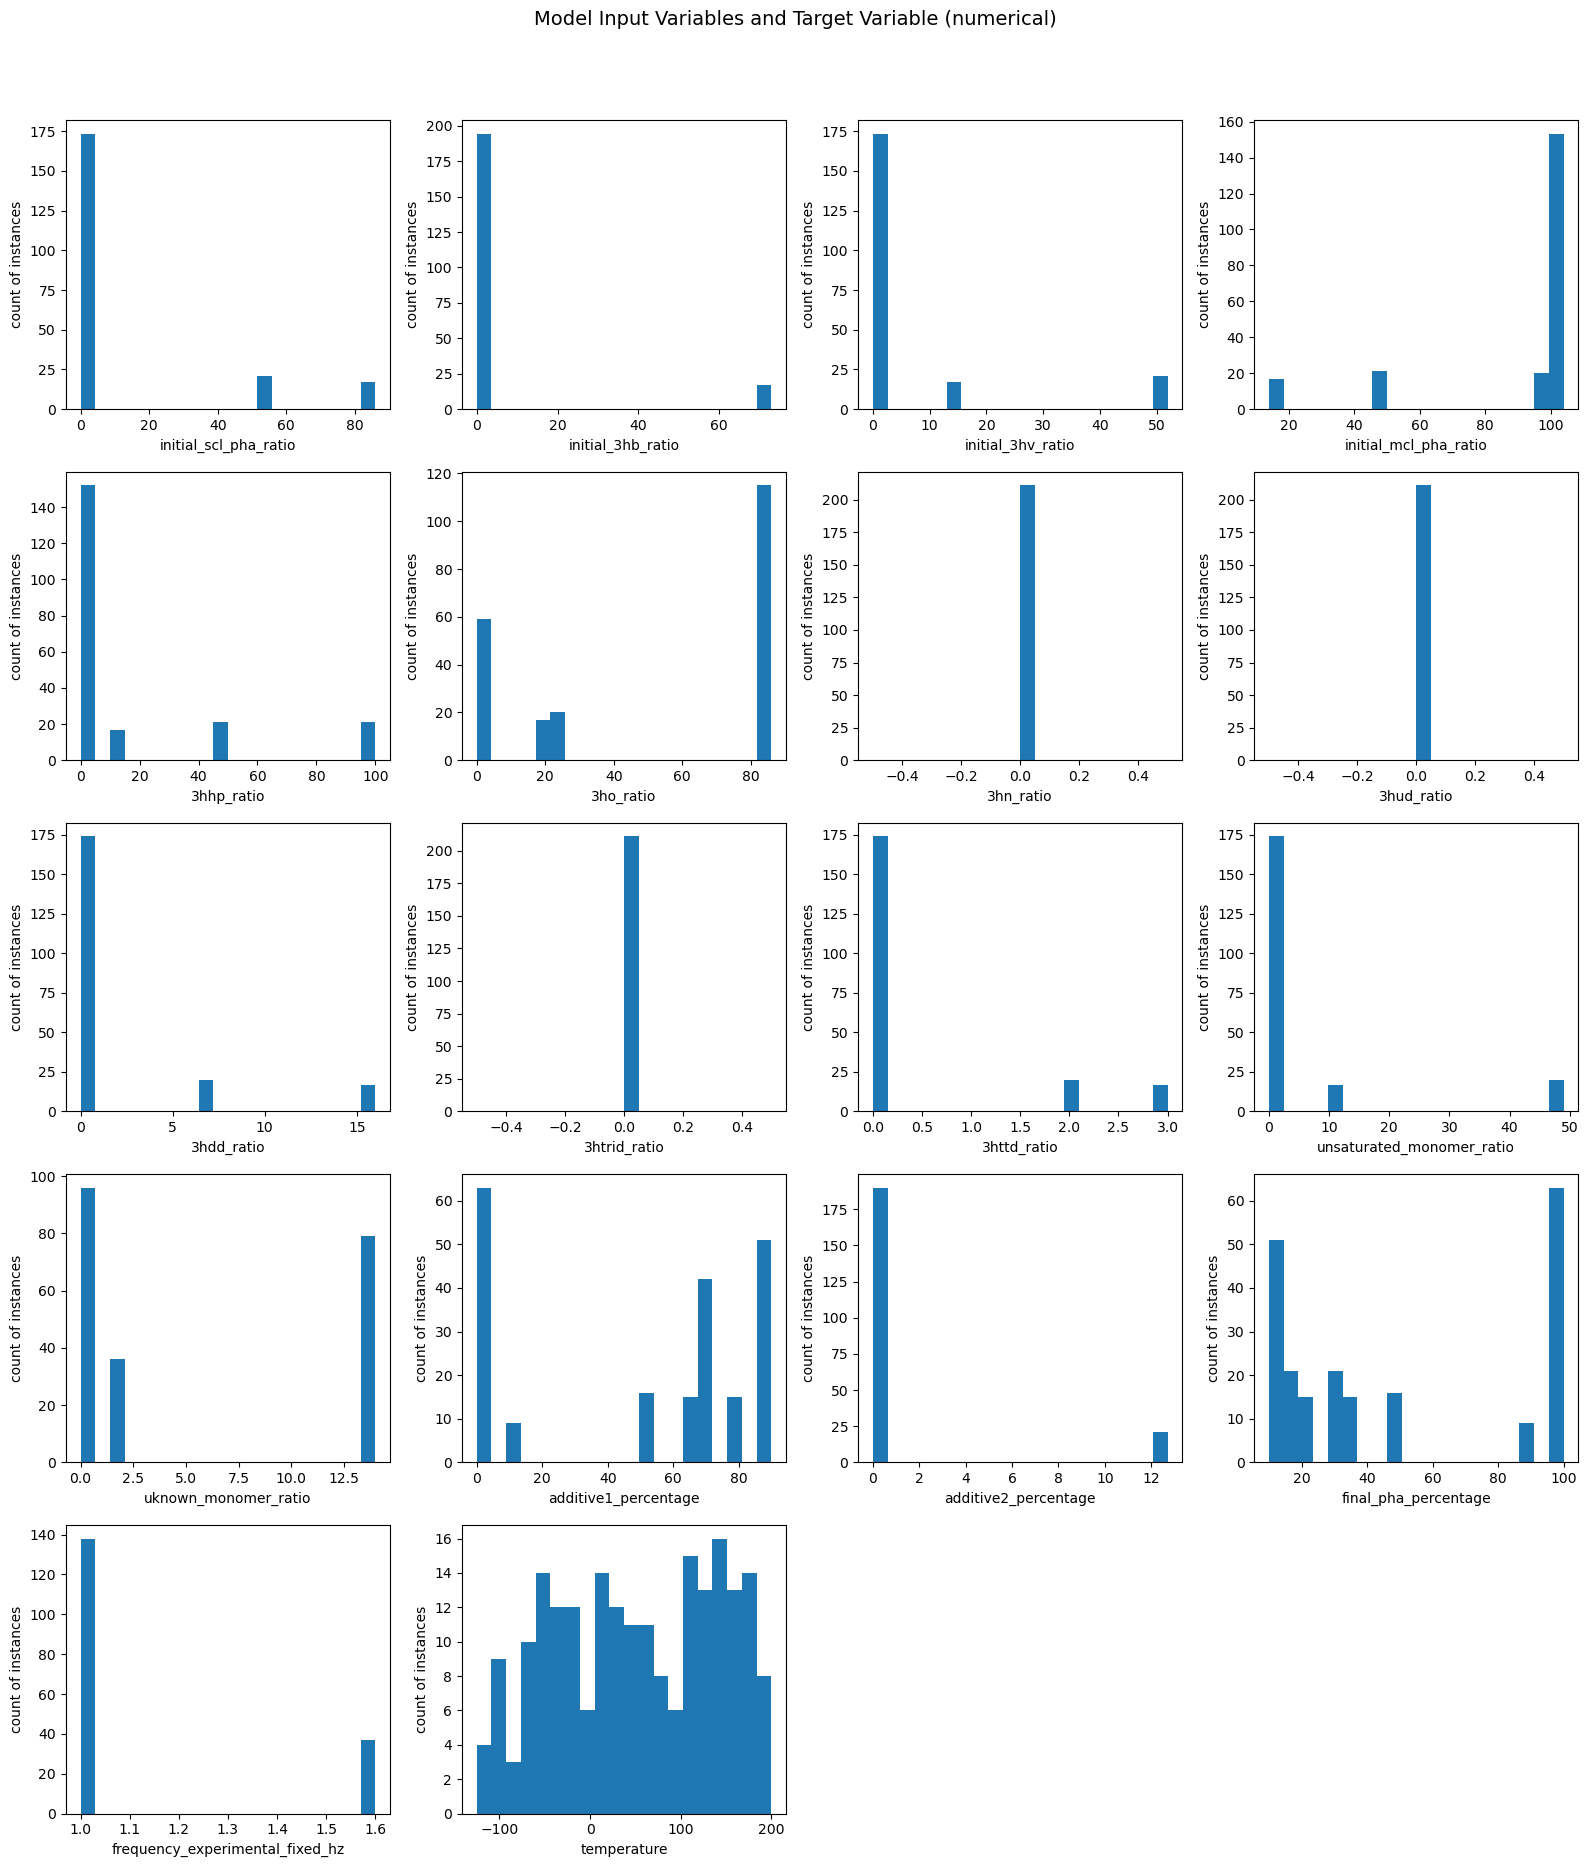

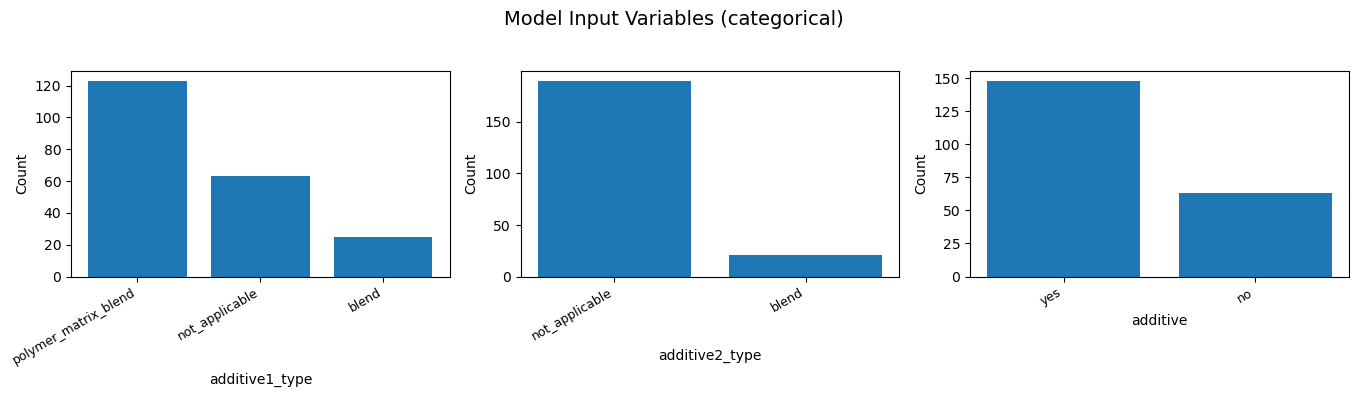

In [28]:
def plot_feature_distributions(
    df: pd.DataFrame,
    numerical_cols,
    categorical_cols,
    title_numeric="Model Input Variables and Target Variable (numerical)",
    title_categorical="Model Input Variables (categorical)",
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,   # cap bars for very high-cardinality cats
):
    # ---------- helper to grid-plot ----------
    def _grid_dims(n, max_cols):
        cols = min(max_cols, max(1, n))
        rows = int(math.ceil(n / cols))
        return rows, cols

    # ---------- NUMERICAL ----------
    if len(numerical_cols) > 0:
        n = len(numerical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.0*cols, 3.8*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_numeric, fontsize=14, y=0.98)

        for i, col in enumerate(numerical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            x = df[col].dropna().values
            ax.hist(x, bins=bins)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    # ---------- CATEGORICAL ----------
    if len(categorical_cols) > 0:
        n = len(categorical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.6*cols, 4.0*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_categorical, fontsize=14, y=0.98)

        for i, col in enumerate(categorical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            vc = (df[col].astype(str).replace("nan", np.nan)
                                 .value_counts(dropna=False)
                                 .head(top_k_categories))
            ax.bar(range(len(vc)), vc.values)
            ax.set_xticks(range(len(vc)))
            ax.set_xticklabels(vc.index.astype(str), rotation=30, ha="right", fontsize=9)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("Count")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

plot_feature_distributions(
    df_clean,
    numerical_cols_lst,
    categorical_cols_lst,
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,
)

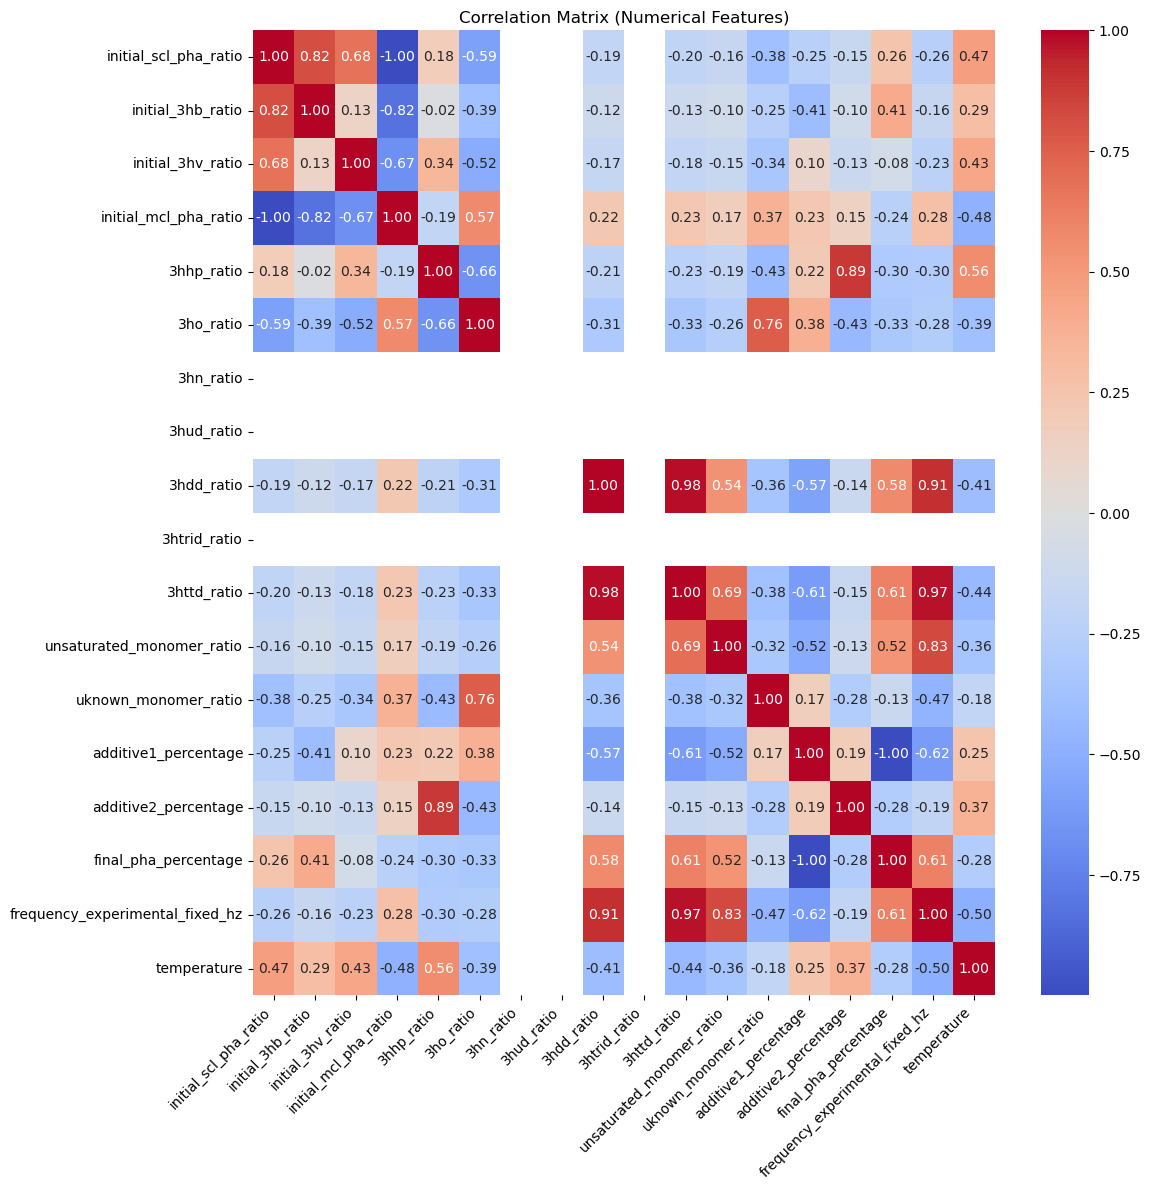

In [29]:
numerical_df = df_clean[numerical_cols_lst].copy()

# Compute correlation matrix
corr_matrix = numerical_df.corr() 

plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix (Numerical Features)")
plt.xticks(rotation=45, ha="right") 
plt.yticks(rotation=0) 

plt.tight_layout()
# plt.savefig("correlation.tiff", format="tiff", dpi=600, bbox_inches="tight")
plt.show()

In [30]:
# Select Features and Target
features = [
            'study_id', 'instance', 'initial_3hb_ratio',
       'initial_3hv_ratio', 'initial_mcl_pha_ratio', '3hhp_ratio', '3ho_ratio',
       '3hn_ratio', '3hud_ratio', '3hdd_ratio', '3htrid_ratio', '3httd_ratio',
       'unsaturated_monomer_ratio', 'uknown_monomer_ratio', 'additive',
       'additive1_type', 'additive1_percentage', 'additive2_type', 'additive2_percentage', 'frequency_experimental_fixed_hz', 'temperature'
           ]

target = 'loss_modulus'
measure_unit = 'MPa'

In [31]:
# Create cleaned DataFrame
df_new = df_clean[features + [target]]

df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 211 entries, 9 to 330
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   study_id                         211 non-null    int64  
 1   instance                         211 non-null    int64  
 2   initial_3hb_ratio                211 non-null    float64
 3   initial_3hv_ratio                211 non-null    float64
 4   initial_mcl_pha_ratio            211 non-null    float64
 5   3hhp_ratio                       211 non-null    float64
 6   3ho_ratio                        211 non-null    float64
 7   3hn_ratio                        211 non-null    float64
 8   3hud_ratio                       211 non-null    int64  
 9   3hdd_ratio                       211 non-null    int64  
 10  3htrid_ratio                     211 non-null    int64  
 11  3httd_ratio                      211 non-null    int64  
 12  unsaturated_monomer_ratio  

## Drop rows with nan value

In [32]:
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]]
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

# Check the DataFrame
df_final.head()

,study_id,instance,initial_3hb_ratio,initial_3hv_ratio,initial_mcl_pha_ratio,3hhp_ratio,3ho_ratio,3hn_ratio,3hud_ratio,3hdd_ratio,...,unsaturated_monomer_ratio,uknown_monomer_ratio,additive,additive1_type,additive1_percentage,additive2_type,additive2_percentage,frequency_experimental_fixed_hz,temperature,loss_modulus
9,7,1,72.9,13.1,14.0,14.0,0.0,0.0,0,0,...,0,0.0,no,not_applicable,0.0,not_applicable,0.0,1.0,100.0,1220.086
10,7,1,72.9,13.1,14.0,14.0,0.0,0.0,0,0,...,0,0.0,no,not_applicable,0.0,not_applicable,0.0,1.0,105.0,918.996
11,7,1,72.9,13.1,14.0,14.0,0.0,0.0,0,0,...,0,0.0,no,not_applicable,0.0,not_applicable,0.0,1.0,110.0,669.939
12,7,1,72.9,13.1,14.0,14.0,0.0,0.0,0,0,...,0,0.0,no,not_applicable,0.0,not_applicable,0.0,1.0,115.0,556.624
13,7,1,72.9,13.1,14.0,14.0,0.0,0.0,0,0,...,0,0.0,no,not_applicable,0.0,not_applicable,0.0,1.0,120.0,452.503


In [33]:
df_final['temperature'].describe()

count    175.000000
mean      56.857143
std       94.407451
min     -125.000000
25%      -27.500000
50%       65.000000
75%      145.000000
max      200.000000
Name: temperature, dtype: float64

In [34]:
df_final['loss_modulus'].describe()

count    1.750000e+02
mean     3.467497e+06
std      1.199132e+07
min      1.056423e-01
25%      8.965133e+01
50%      4.904370e+02
75%      4.651532e+04
max      7.961594e+07
Name: loss_modulus, dtype: float64

In [35]:
df_final = df_final.copy()
df_final['log_loss_modulus'] = np.log10(df_final['loss_modulus'])
# df_final['log_mw'] = np.log10(df_final['mw_phbv'])

In [36]:
df_final.columns

Index(['study_id', 'instance', 'initial_3hb_ratio', 'initial_3hv_ratio',
       'initial_mcl_pha_ratio', '3hhp_ratio', '3ho_ratio', '3hn_ratio',
       '3hud_ratio', '3hdd_ratio', '3htrid_ratio', '3httd_ratio',
       'unsaturated_monomer_ratio', 'uknown_monomer_ratio', 'additive',
       'additive1_type', 'additive1_percentage', 'additive2_type',
       'additive2_percentage', 'frequency_experimental_fixed_hz',
       'temperature', 'loss_modulus', 'log_loss_modulus'],
      dtype='object')

## Remove features with only one value

In [37]:
constant_cols = df_final.columns[df_final.nunique(dropna=True) <= 1]
print("Removed columns:", list(constant_cols))
df_final = df_final.drop(columns=constant_cols)

Removed columns: ['3hn_ratio', '3hud_ratio', '3htrid_ratio']


In [38]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175 entries, 9 to 330
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   study_id                         175 non-null    int64  
 1   instance                         175 non-null    int64  
 2   initial_3hb_ratio                175 non-null    float64
 3   initial_3hv_ratio                175 non-null    float64
 4   initial_mcl_pha_ratio            175 non-null    float64
 5   3hhp_ratio                       175 non-null    float64
 6   3ho_ratio                        175 non-null    float64
 7   3hdd_ratio                       175 non-null    int64  
 8   3httd_ratio                      175 non-null    int64  
 9   unsaturated_monomer_ratio        175 non-null    int64  
 10  uknown_monomer_ratio             175 non-null    float64
 11  additive                         175 non-null    object 
 12  additive1_type             

## Save

In [39]:
df_final.to_csv('rheological_DTS_mcl_loss_LM.csv', index=False)

## Profiling

In [40]:
import sweetviz as sv

exclude_cols = ['study_id', 'instance']
df_subset = df_final.drop(columns=exclude_cols)

report = sv.analyze(df_subset)
report.show_html("dataset_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report dataset_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
